# AgroPredict v2 — EDA (Google Colab version)
### Indian Crop Recommendation Dataset (140 crops, 100,000 rows)

This is the Colab-adapted version of the EDA: it mounts your Google Drive instead of reading local
files, and adds a **statistical feature justification** section (ANOVA F-test + mutual information)
so feature choices are backed by numbers, not just "the boxplot looked separated."

**Sections**
1. Colab setup — mount Drive, set data path
2. Data load
3. Structural overview
4. Target variable — crop distribution
5. Numeric feature distributions
6. Correlation analysis
7. **Statistical feature justification** (new)
8. Categorical features — soil_type & season
9. Feature relationships by season / soil_type
10. Crop-level patterns
11. Geography (context only — not used in Model A)
12. Range / sanity checks
13. Encoding & scaling implications
14. ICRISAT real-data plausibility check
15. Summary of findings & recommendations


## 1. Colab setup

Mounts your Drive so the notebook can read the files you uploaded. **Edit `DATA_DIR` below** to
match wherever you put the four CSVs (`indian_crop_training_dataset.csv`, `crop_profiles.csv`,
`data_dictionary.csv`, `real_indian_crop_validation_dataset.csv`) in your Drive.

In [32]:
import os

# EDIT THIS to the folder in your Drive that contains the CSVs
DATA_DIR = "/content/"

expected_files = [
    "indian_crop_training_dataset.csv",
    "crop_profiles.csv",
    "data_dictionary.csv",
    "real_indian_crop_validation_dataset.csv",
]
missing = [f for f in expected_files if not os.path.exists(os.path.join(DATA_DIR, f))]
if missing:
    print("Could not find these files in DATA_DIR -- fix the path above:")
    for f in missing:
        print(" -", f)
    print()
    print("Contents of DATA_DIR:")
    print(os.listdir(DATA_DIR) if os.path.isdir(DATA_DIR) else "DATA_DIR does not exist")
else:
    print("All expected files found in", DATA_DIR)


All expected files found in /content/


## 2. Data load

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import f_classif, mutual_info_classif
from sklearn.preprocessing import LabelEncoder

%matplotlib inline
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 50)

NUMERIC_FEATURES = [
    "nitrogen_N_kg_ha", "phosphorus_P_kg_ha", "potassium_K_kg_ha",
    "temperature_C", "humidity_percent", "rainfall_mm",
    "soil_pH", "soil_moisture_percent",
]
CATEGORICAL_FEATURES = ["soil_type", "season"]
GEO_FEATURES = ["state", "latitude", "longitude"]  # context only, not in Model A
TARGET = "crop"


In [34]:
df = pd.read_csv(os.path.join(DATA_DIR, "indian_crop_training_dataset.csv"))
crop_profiles = pd.read_csv(os.path.join(DATA_DIR, "crop_profiles.csv"))
data_dict = pd.read_csv(os.path.join(DATA_DIR, "data_dictionary.csv"))
real_df = pd.read_csv(os.path.join(DATA_DIR, "real_indian_crop_validation_dataset.csv"))

print(f"Training data: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"ICRISAT validation data: {real_df.shape[0]:,} rows x {real_df.shape[1]} columns")
df.head()


Training data: 100,000 rows x 14 columns
ICRISAT validation data: 656 rows x 22 columns


,crop,nitrogen_N_kg_ha,phosphorus_P_kg_ha,potassium_K_kg_ha,temperature_C,humidity_percent,rainfall_mm,soil_pH,soil_moisture_percent,soil_type,season,state,latitude,longitude
0,rice,288.8,33.1,211.2,33.0,80.3,1568.8,6.73,53.9,Alluvial,Kharif,Assam,26.69767,94.30516
1,cabbage,288.5,30.6,167.0,19.2,61.4,762.2,6.30,48.5,Mountain/forest soil,Rabi,Himachal Pradesh,31.12325,77.21718
2,jackfruit,288.1,85.0,265.8,27.1,77.6,1181.2,6.46,59.0,Coastal/alluvial,Perennial,Kerala,9.37961,76.39760
3,taro,198.9,61.8,317.1,20.3,72.4,766.9,7.80,36.2,Alluvial,Rabi,Odisha,20.44133,85.91780
4,rye,246.5,71.6,162.3,13.8,58.7,528.4,7.51,29.2,Loamy,Rabi,Himachal Pradesh,31.90560,77.04182


## 3. Structural overview

Checking shape, dtypes, missing values and duplicates before trusting any downstream stats.

In [35]:
print("dtypes:")
print(df.dtypes)
print()
print("Missing values per column:")
print(df.isnull().sum())
print()
print(f"Total missing cells: {df.isnull().sum().sum()}")
print(f"Fully duplicated rows: {df.duplicated().sum()}")


dtypes:
crop                      object
nitrogen_N_kg_ha         float64
phosphorus_P_kg_ha       float64
potassium_K_kg_ha        float64
temperature_C            float64
humidity_percent         float64
rainfall_mm              float64
soil_pH                  float64
soil_moisture_percent    float64
soil_type                 object
season                    object
state                     object
latitude                 float64
longitude                float64
dtype: object

Missing values per column:
crop                     0
nitrogen_N_kg_ha         0
phosphorus_P_kg_ha       0
potassium_K_kg_ha        0
temperature_C            0
humidity_percent         0
rainfall_mm              0
soil_pH                  0
soil_moisture_percent    0
soil_type                0
season                   0
state                    0
latitude                 0
longitude                0
dtype: int64

Total missing cells: 0
Fully duplicated rows: 0


In [36]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
crop,100000,140,rice,715,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nitrogen_N_kg_ha,100000.0,NaN,NaN,NaN,283.340671,85.248403,80.0,225.1,283.45,341.7,650.0
phosphorus_P_kg_ha,100000.0,NaN,NaN,NaN,49.696904,19.512908,8.4,35.6,46.3,60.0,120.0
potassium_K_kg_ha,100000.0,NaN,NaN,NaN,241.168283,109.56599,40.0,161.9,219.2,296.5,650.0
temperature_C,100000.0,NaN,NaN,NaN,25.016313,4.655135,6.3,22.3,25.7,28.3,37.5
humidity_percent,100000.0,NaN,NaN,NaN,64.204711,9.942559,27.8,57.3,64.0,71.1,97.0
rainfall_mm,100000.0,NaN,NaN,NaN,915.049979,591.733682,178.0,477.3,721.3,1177.125,3572.0
soil_pH,100000.0,NaN,NaN,NaN,6.668749,0.686284,4.5,6.23,6.71,7.15,8.5
soil_moisture_percent,100000.0,NaN,NaN,NaN,39.349035,11.062856,8.0,31.7,39.4,46.9,81.9
soil_type,100000,10,Alluvial,24986,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Target variable — crop distribution

140 crop classes. Checking class balance matters: if it's genuinely even, we don't need
class-weighting or resampling, and stratified splits/CV will behave well.

Number of unique crops: 140
Min class count: 714  |  Max class count: 715
Std dev of class counts: 0.45


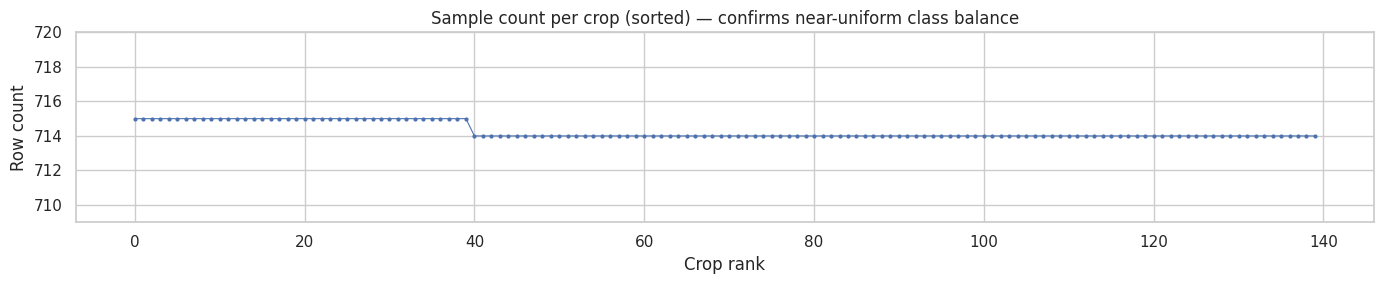

In [37]:
crop_counts = df[TARGET].value_counts()
print(f"Number of unique crops: {df[TARGET].nunique()}")
print(f"Min class count: {crop_counts.min()}  |  Max class count: {crop_counts.max()}")
print(f"Std dev of class counts: {crop_counts.std():.2f}")

fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(range(len(crop_counts)), crop_counts.values, marker="o", markersize=2, linewidth=0.8)
ax.set_title("Sample count per crop (sorted) — confirms near-uniform class balance")
ax.set_xlabel("Crop rank")
ax.set_ylabel("Row count")
ax.set_ylim(crop_counts.min() - 5, crop_counts.max() + 5)
plt.tight_layout()
plt.show()


## 5. Numeric feature distributions

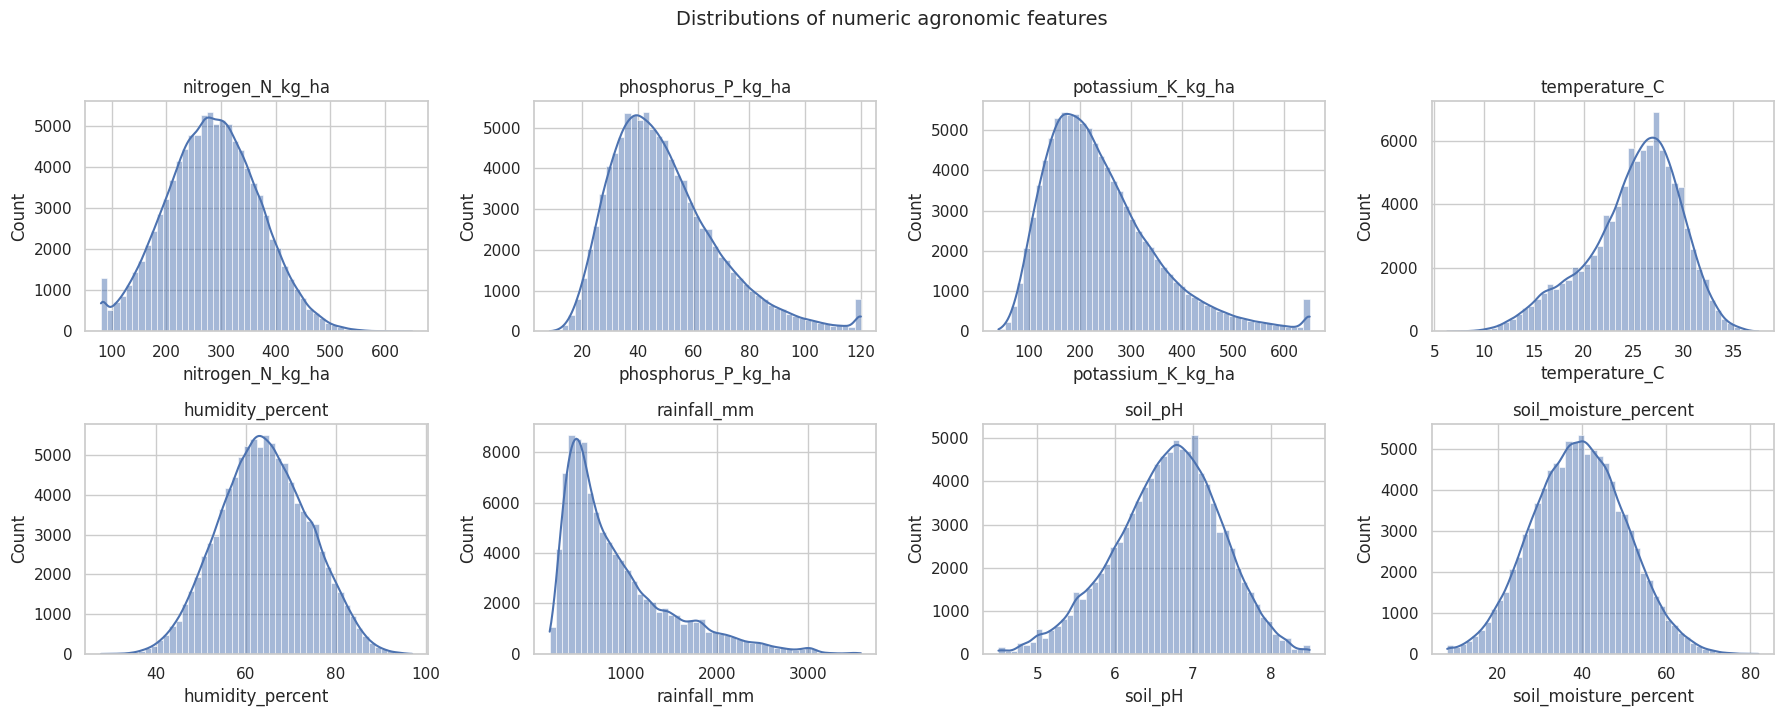

In [38]:
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for ax, feat in zip(axes.flat, NUMERIC_FEATURES):
    sns.histplot(df[feat], bins=50, ax=ax, kde=True)
    ax.set_title(feat)
plt.suptitle("Distributions of numeric agronomic features", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


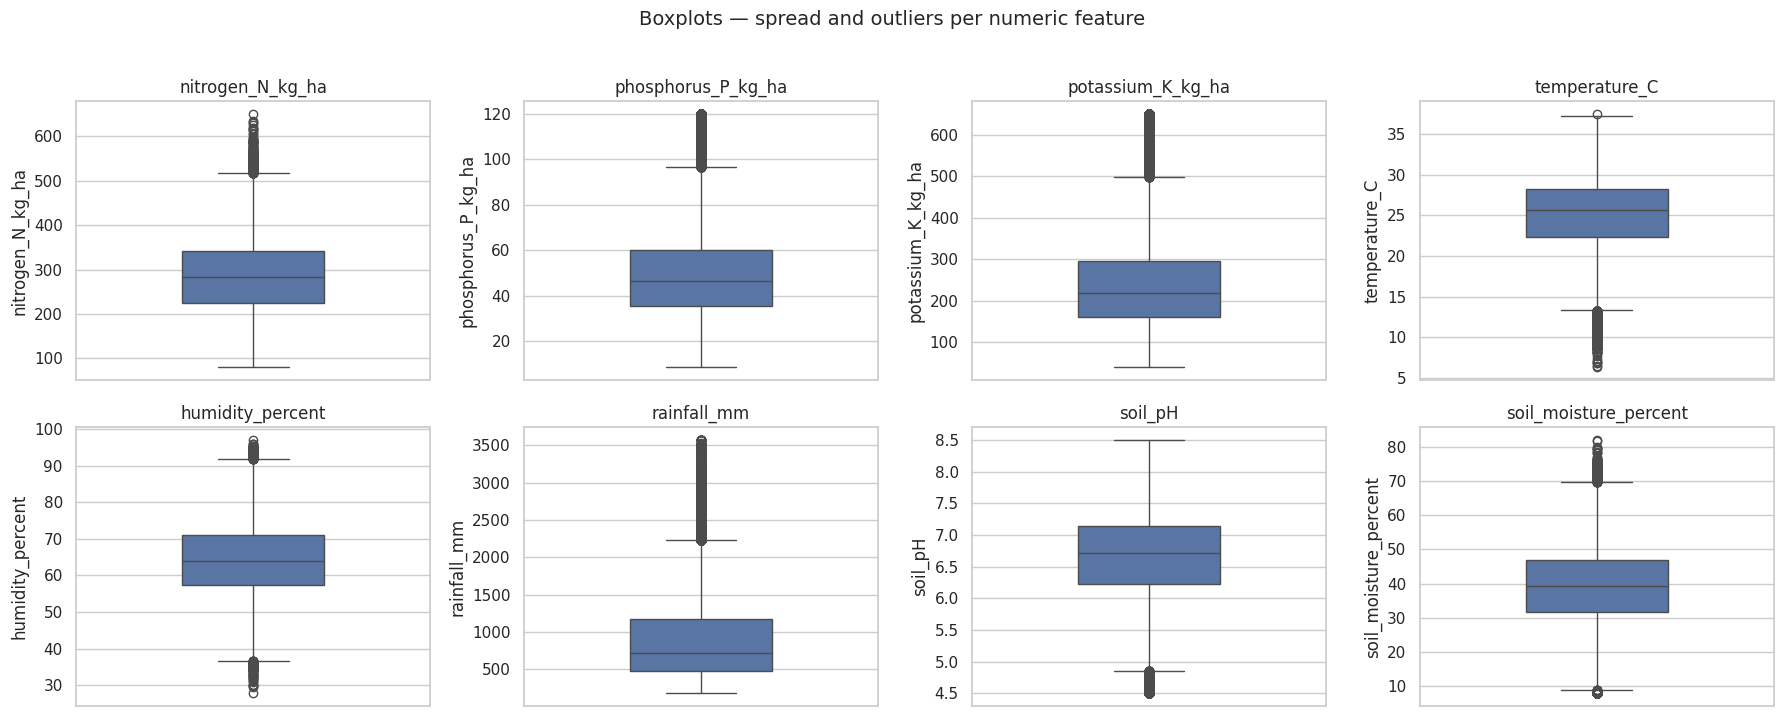

In [39]:
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for ax, feat in zip(axes.flat, NUMERIC_FEATURES):
    sns.boxplot(y=df[feat], ax=ax, width=0.4)
    ax.set_title(feat)
plt.suptitle("Boxplots — spread and outliers per numeric feature", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


## 6. Correlation analysis

Checking pairwise linear relationships among the numeric features, including the rainfall/soil-moisture
correlation the dataset's README claims (0.6411 by design).

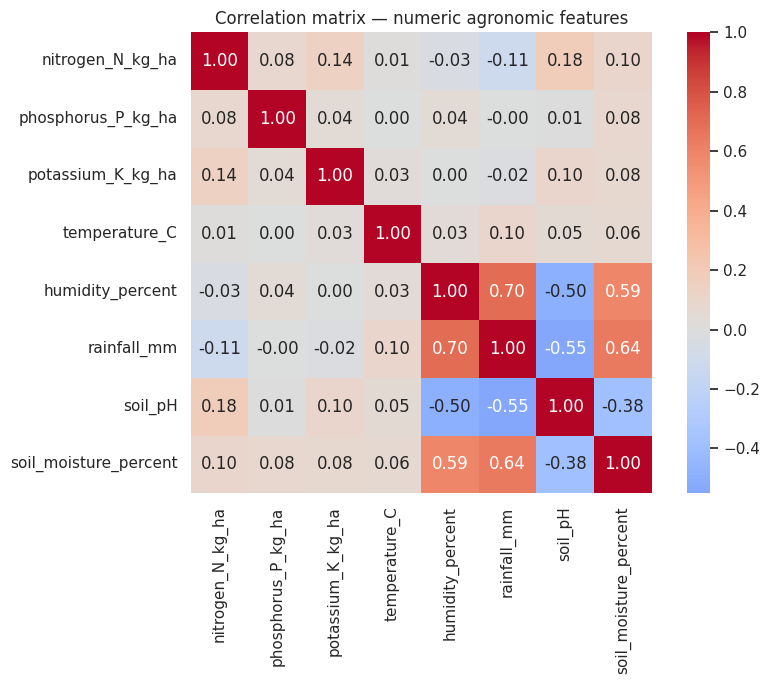

rainfall_mm vs soil_moisture_percent correlation: 0.6411


In [40]:
corr = df[NUMERIC_FEATURES].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, ax=ax)
ax.set_title("Correlation matrix — numeric agronomic features")
plt.tight_layout()
plt.show()

print(f"rainfall_mm vs soil_moisture_percent correlation: {corr.loc['rainfall_mm','soil_moisture_percent']:.4f}")


## 7. Statistical feature justification

Correlation and boxplots are a good start, but they don't formally test *how much a feature
separates the 140 crop classes*. Two complementary statistical tests do that:

- **ANOVA F-test** (`f_classif`) — for each numeric feature, tests whether its mean differs
  significantly across the 140 crop groups. Captures **linear** separability. Larger F-statistic =
  stronger separation between at least some crop groups on that feature.
- **Mutual information** (`mutual_info_classif`) — measures general statistical dependency between
  a feature and the target, including **non-linear** relationships that ANOVA can miss. Works for
  both numeric and categorical features (categoricals are label-encoded first and flagged as
  discrete), so it lets us rank `soil_type` and `season` on the same scale as the numeric features.

**Important caveat to internalize (and worth stating explicitly if you write this up):** with
100,000 rows, p-values from the F-test will be astronomically small for almost any real effect —
statistical significance is nearly guaranteed at this sample size. The **F-statistic / MI value**
(effect size) is what actually matters here, not whether p < 0.05.

**Second caveat:** both tests are *univariate* — they look at one feature at a time and cannot see
interactions (e.g. rainfall combined with soil type might matter more jointly than either alone).
Tree-based feature importances and SHAP later in the project will pick up interaction effects that
this section structurally cannot.

ANOVA F-test ranking (numeric features, linear separability):
                       F_statistic  p_value
rainfall_mm            1544.812231      0.0
soil_moisture_percent  1021.794143      0.0
temperature_C          1017.596671      0.0
soil_pH                 677.699523      0.0
humidity_percent        595.980100      0.0
nitrogen_N_kg_ha         90.460367      0.0
potassium_K_kg_ha        41.040234      0.0
phosphorus_P_kg_ha       34.353910      0.0


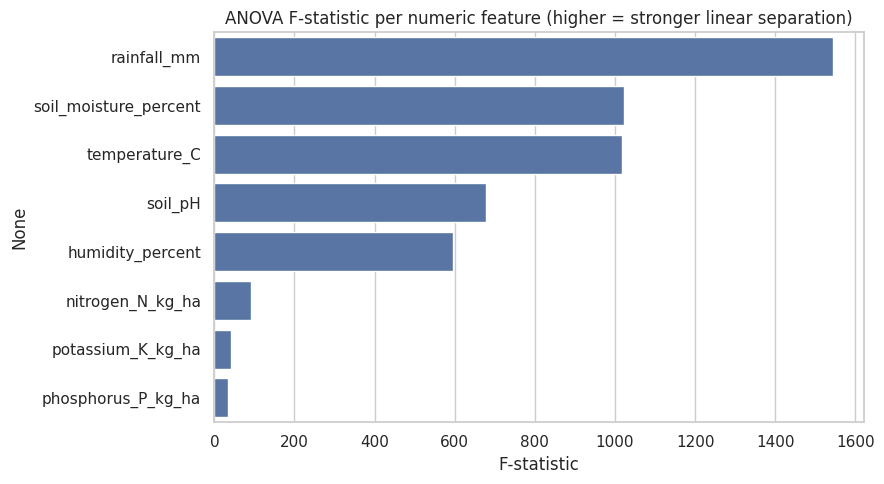

In [41]:
# ANOVA F-test -- numeric features only, linear separability across 140 crop classes
f_vals, p_vals = f_classif(df[NUMERIC_FEATURES], df[TARGET])
anova_result = pd.DataFrame(
    {"F_statistic": f_vals, "p_value": p_vals}, index=NUMERIC_FEATURES
).sort_values("F_statistic", ascending=False)

print("ANOVA F-test ranking (numeric features, linear separability):")
print(anova_result)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=anova_result["F_statistic"], y=anova_result.index, ax=ax, orient="h")
ax.set_title("ANOVA F-statistic per numeric feature (higher = stronger linear separation)")
ax.set_xlabel("F-statistic")
plt.tight_layout()
plt.show()


Mutual information ranking (numeric + categorical, general dependency):
rainfall_mm              1.156444
season                   0.662013
soil_type                0.656180
soil_moisture_percent    0.449534
temperature_C            0.407881
humidity_percent         0.361847
soil_pH                  0.354877
nitrogen_N_kg_ha         0.063619
phosphorus_P_kg_ha       0.028088
potassium_K_kg_ha        0.027661
dtype: float64


/tmp/ipykernel_2717/1499063149.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mi_result.values, y=mi_result.index, ax=ax, orient="h", palette=colors)


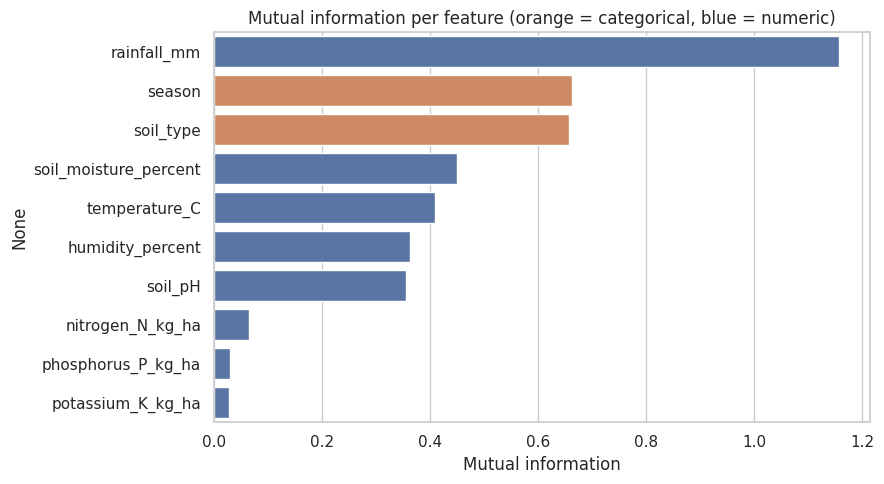

In [42]:
# Mutual information -- numeric AND categorical features together, on one comparable scale
X_mi = df[NUMERIC_FEATURES].copy()
for c in CATEGORICAL_FEATURES:
    X_mi[c] = LabelEncoder().fit_transform(df[c])

discrete_mask = [False] * len(NUMERIC_FEATURES) + [True] * len(CATEGORICAL_FEATURES)

mi_vals = mutual_info_classif(X_mi, df[TARGET], discrete_features=discrete_mask, random_state=42)
mi_result = pd.Series(mi_vals, index=X_mi.columns).sort_values(ascending=False)

print("Mutual information ranking (numeric + categorical, general dependency):")
print(mi_result)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#DD8452" if c in CATEGORICAL_FEATURES else "#4C72B0" for c in mi_result.index]
sns.barplot(x=mi_result.values, y=mi_result.index, ax=ax, orient="h", palette=colors)
ax.set_title("Mutual information per feature (orange = categorical, blue = numeric)")
ax.set_xlabel("Mutual information")
plt.tight_layout()
plt.show()


**What this actually showed (from the run against the training data):**

- `rainfall_mm` is the single strongest feature by both tests — highest ANOVA F-statistic and
  highest mutual information by a wide margin. This lines up with agronomic intuition: crop-cycle
  rainfall requirement is one of the most crop-defining variables in India.
- `season` and `soil_type` rank right behind rainfall in mutual information — unsurprising once you
  recall the generation methodology restricts each crop to specific documented seasons/soil classes
  (see `crop_profiles.csv`), so these categoricals carry a lot of near-deterministic signal.
- `soil_moisture_percent`, `temperature_C`, `soil_pH` and `humidity_percent` form a consistent
  "moderately strong" middle tier in **both** tests — a good sign, since two different statistical
  methods agreeing adds confidence it's a real signal, not a test artifact.
- `nitrogen_N_kg_ha`, `phosphorus_P_kg_ha`, `potassium_K_kg_ha` rank lowest on both tests. This
  matches the dataset README directly — it states N/P/K were generated with **"overlapping
  distributions"** across crops, i.e. they were never designed to individually discriminate crop
  identity as cleanly as rainfall or season. That does **not** mean drop them: it means their value
  is more likely to show up in combination with other features (interaction effects) or through
  agronomic domain relevance (a farmer directly controls N/P/K via fertilization, unlike rainfall) —
  worth checking against Random Forest `feature_importances_` and SHAP later, as a direct comparison
  between "statistics before any model" and "signal the trained model actually uses."


## 8. Categorical features — soil_type & season

Confirming category counts and cardinality for encoding purposes (both need to be reflected in the
FastAPI Pydantic models and frontend form).

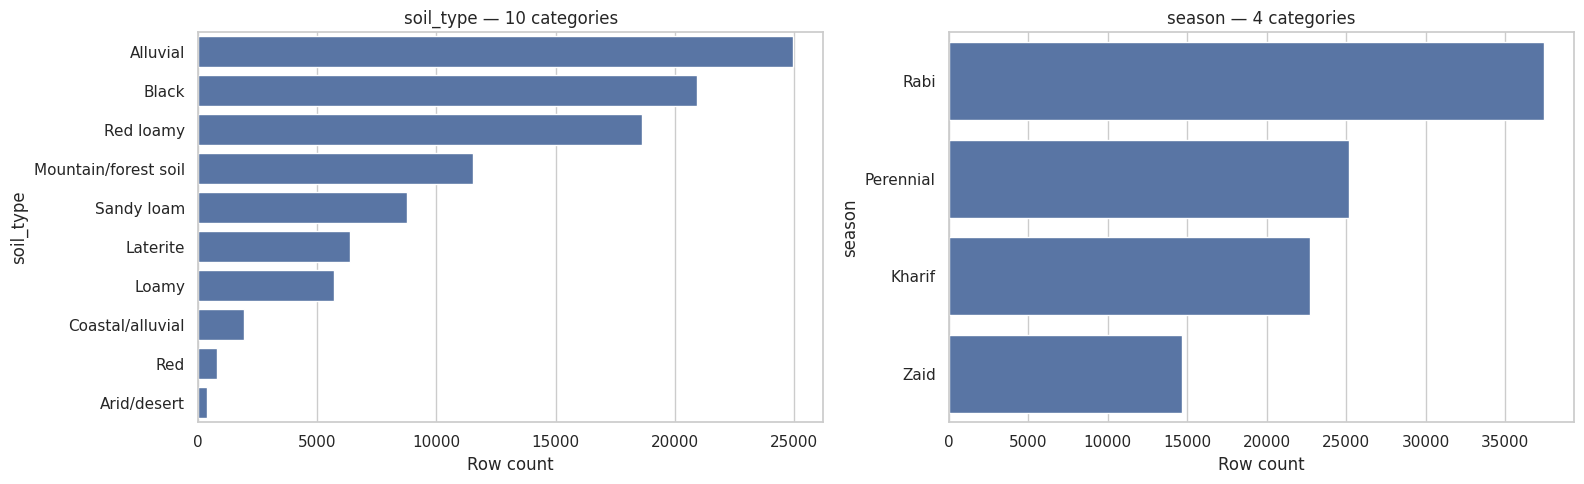

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

soil_counts = df["soil_type"].value_counts()
sns.barplot(x=soil_counts.values, y=soil_counts.index, ax=axes[0], orient="h")
axes[0].set_title(f"soil_type — {df['soil_type'].nunique()} categories")
axes[0].set_xlabel("Row count")

season_counts = df["season"].value_counts()
sns.barplot(x=season_counts.values, y=season_counts.index, ax=axes[1], orient="h")
axes[1].set_title(f"season — {df['season'].nunique()} categories")
axes[1].set_xlabel("Row count")

plt.tight_layout()
plt.show()


## 9. Feature relationships by season / soil_type

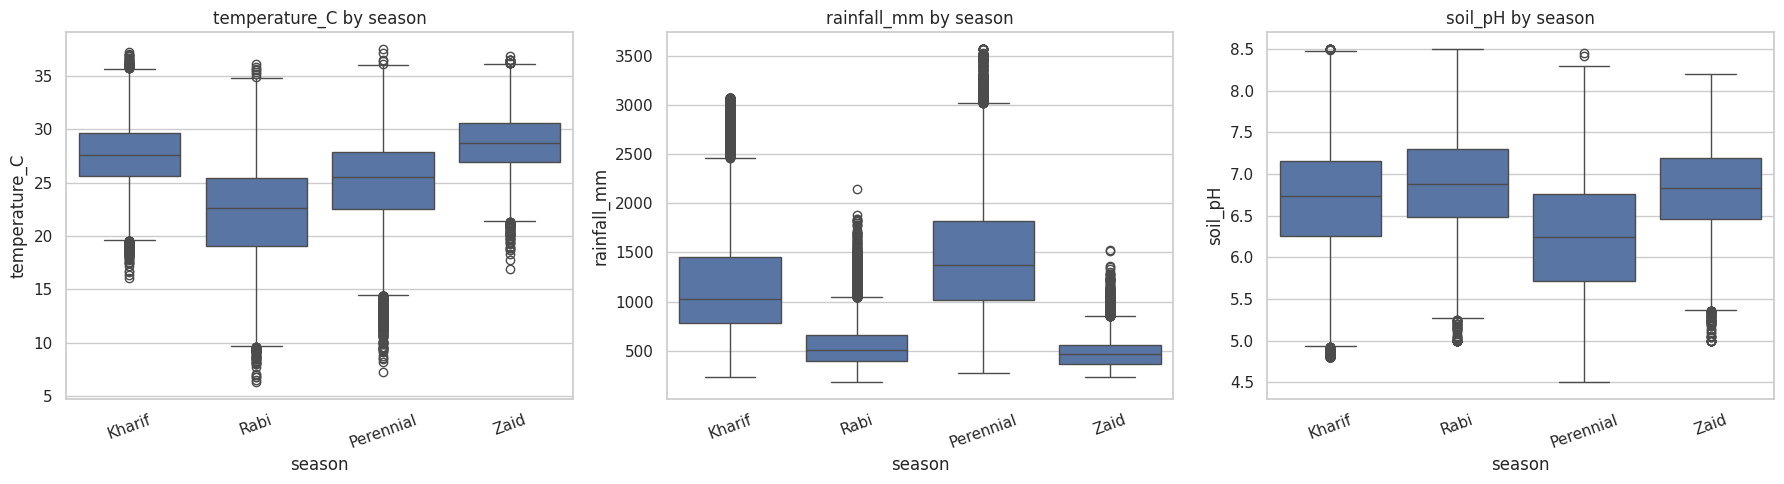

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, feat in zip(axes, ["temperature_C", "rainfall_mm", "soil_pH"]):
    sns.boxplot(data=df, x="season", y=feat, ax=ax)
    ax.set_title(f"{feat} by season")
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()


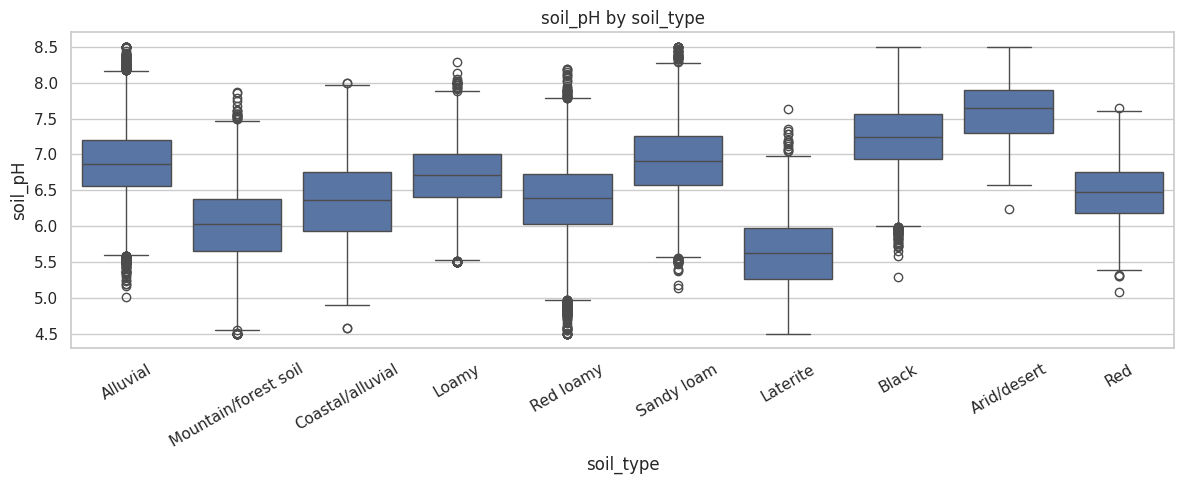

In [45]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=df, x="soil_type", y="soil_pH", ax=ax)
ax.set_title("soil_pH by soil_type")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


## 10. Crop-level patterns

140 individual crops are too many for a legible per-crop plot grid, so this aggregates via
`crop_category` (from `crop_profiles.csv`) and ranks crops at the rainfall/temperature extremes.

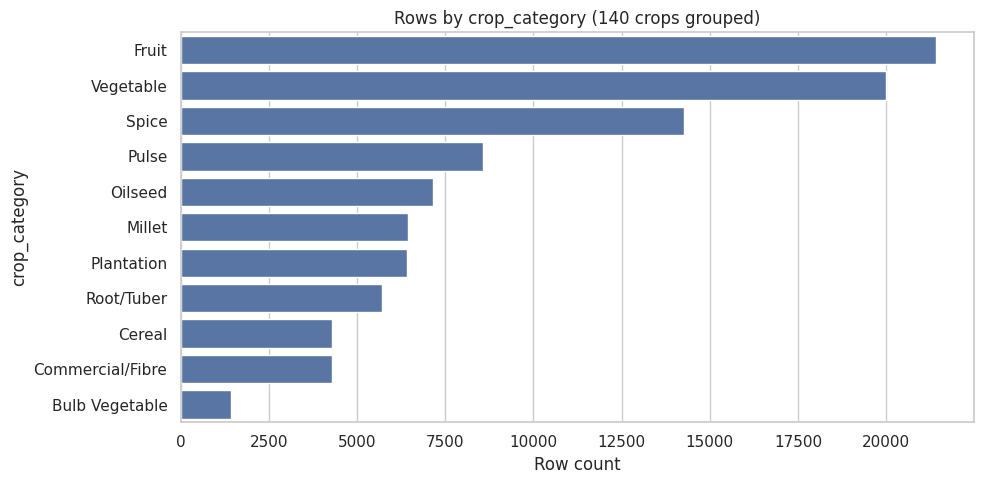

Unmapped crop_category rows: 0


In [46]:
cat_map = crop_profiles.set_index("crop")["crop_category"]
df["crop_category"] = df["crop"].map(cat_map)

cat_counts = df["crop_category"].value_counts()
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=cat_counts.values, y=cat_counts.index, ax=ax, orient="h")
ax.set_title("Rows by crop_category (140 crops grouped)")
ax.set_xlabel("Row count")
plt.tight_layout()
plt.show()

print(f"Unmapped crop_category rows: {df['crop_category'].isnull().sum()}")


/tmp/ipykernel_2717/3581194629.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_bottom_rain["rainfall_mm"], y=top_bottom_rain.index, ax=axes[0],
/tmp/ipykernel_2717/3581194629.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_bottom_temp.values, y=top_bottom_temp.index, ax=axes[1],


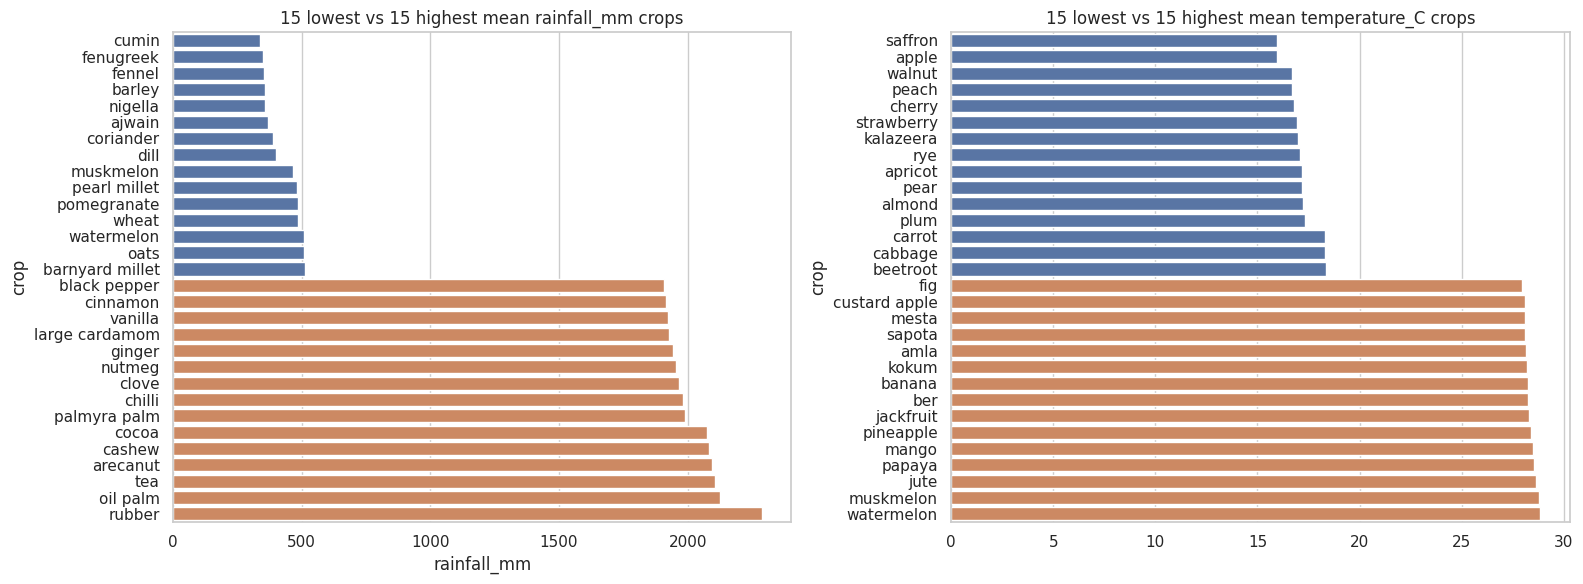

In [47]:
crop_means = df.groupby("crop")[["rainfall_mm", "temperature_C"]].mean().sort_values("rainfall_mm")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_bottom_rain = pd.concat([crop_means.head(15), crop_means.tail(15)])
sns.barplot(x=top_bottom_rain["rainfall_mm"], y=top_bottom_rain.index, ax=axes[0],
            palette=["#4C72B0"]*15 + ["#DD8452"]*15)
axes[0].set_title("15 lowest vs 15 highest mean rainfall_mm crops")

crop_means_temp = df.groupby("crop")["temperature_C"].mean().sort_values()
top_bottom_temp = pd.concat([crop_means_temp.head(15), crop_means_temp.tail(15)])
sns.barplot(x=top_bottom_temp.values, y=top_bottom_temp.index, ax=axes[1],
            palette=["#4C72B0"]*15 + ["#DD8452"]*15)
axes[1].set_title("15 lowest vs 15 highest mean temperature_C crops")

plt.tight_layout()
plt.show()


## 11. Geography (context only — **not** used in Model A)

Shown purely to understand the dataset's geographic footprint. Deliberately excluded from Model A's
feature set to avoid state→crop shortcut learning. Useful later for Model B with grouped-by-state CV.

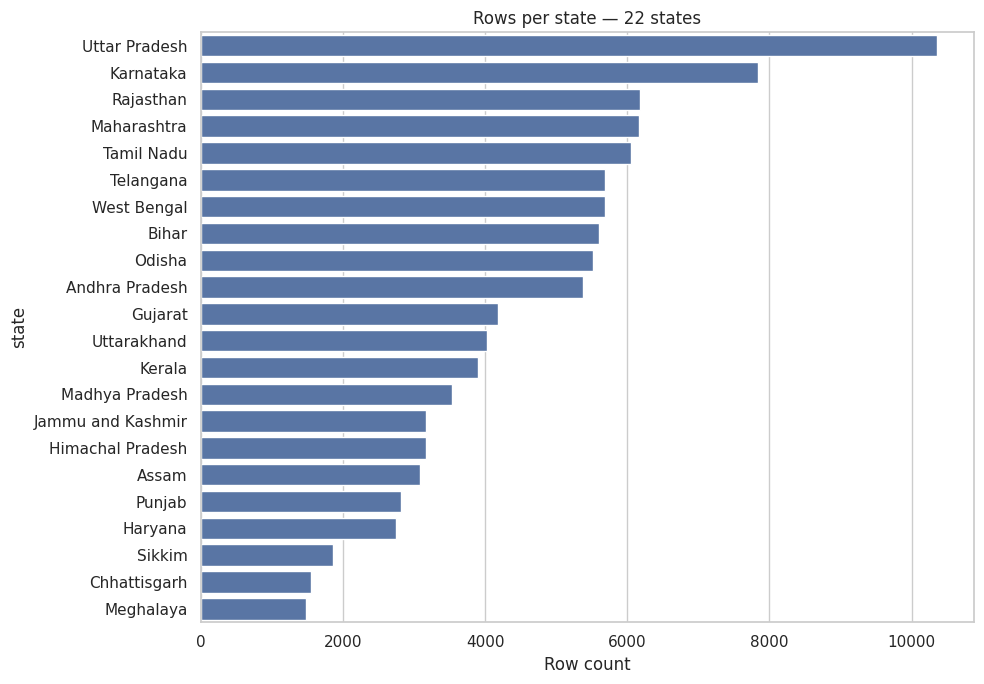

In [48]:
state_counts = df["state"].value_counts()
fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(x=state_counts.values, y=state_counts.index, ax=ax, orient="h")
ax.set_title(f"Rows per state — {df['state'].nunique()} states")
ax.set_xlabel("Row count")
plt.tight_layout()
plt.show()


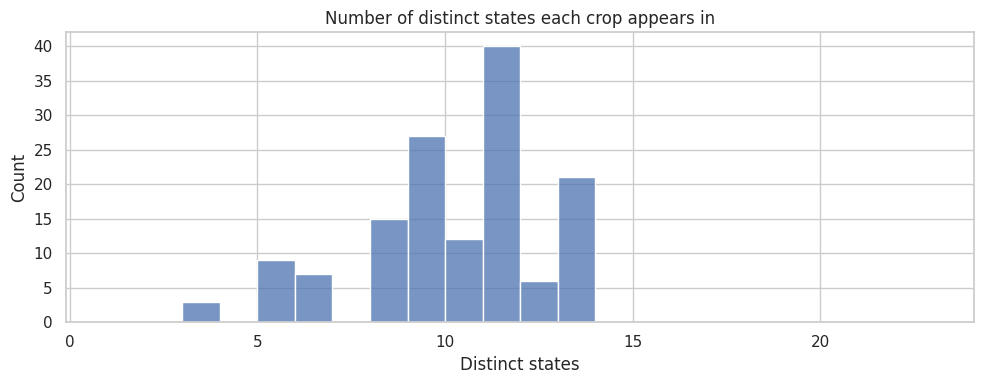

Crops confined to a single state (highest shortcut-learning risk if geography is used):
['saffron', 'rye', 'kalazeera']


In [49]:
states_per_crop = df.groupby("crop")["state"].nunique().sort_values()

fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(states_per_crop, bins=range(1, 24), ax=ax)
ax.set_title("Number of distinct states each crop appears in")
ax.set_xlabel("Distinct states")
plt.tight_layout()
plt.show()

print("Crops confined to a single state (highest shortcut-learning risk if geography is used):")
print(states_per_crop[states_per_crop == states_per_crop.min()].index.tolist())


## 12. Range / sanity checks against the data dictionary

In [50]:
print(f"{'feature':<25}{'actual min':>12}{'actual max':>12}   documented valid_range")
print("-" * 90)
for feat in NUMERIC_FEATURES:
    row = data_dict.loc[data_dict["column_name"] == feat, "valid_range"]
    documented = row.values[0] if len(row) else "n/a"
    print(f"{feat:<25}{df[feat].min():>12.2f}{df[feat].max():>12.2f}   {documented}")


feature                    actual min  actual max   documented valid_range
------------------------------------------------------------------------------------------
nitrogen_N_kg_ha                80.00      650.00   80–650
phosphorus_P_kg_ha               8.40      120.00   5–120
potassium_K_kg_ha               40.00      650.00   40–650
temperature_C                    6.30       37.50   profile-constrained, overall -5–50
humidity_percent                27.80       97.00   0–100
rainfall_mm                    178.00     3572.00   >=0 and crop-profile constrained
soil_pH                          4.50        8.50   3.5–9.5; crop-profile constrained
soil_moisture_percent            8.00       81.90   0–100


## 13. Encoding & scaling implications for modeling

- **`soil_type`** (10 categories) and **`season`** (4 categories): nominal, low-cardinality —
  one-hot encode both.
- Section 7 showed both carry strong statistical signal (high mutual information) — make sure
  they're actually wired into the FastAPI Pydantic request schema as enums, not dropped for
  convenience.
- Tree-based models (Random Forest, Decision Tree, and the boosted models) don't need scaling.
  **KNN and SVC do** — fit `StandardScaler` on the training split only.
- No missing values, no duplicates — no imputation/dedup step needed.
- Class balance is near-perfect — stratified CV will work cleanly, no class-weighting needed.
- `state`, `latitude`, `longitude` stay **out of Model A's feature matrix entirely** (not just
  dropped at train time) to avoid leaking them into a serialized pipeline.
- N/P/K ranked weakest in Section 7's univariate tests — flag this now as something to specifically
  check against Random Forest/boosted-model `feature_importances_` and SHAP values later. If the
  trained model also barely uses them, that's a defensible, evidence-backed thing to discuss in your
  write-up (not a bug to "fix").

In [51]:
## 13. Encoding & scaling implications for modeling

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# --- Confirm the ground truth this section relies on (from Sections 3, 4, 7) ---
assert df[NUMERIC_FEATURES + CATEGORICAL_FEATURES].isnull().sum().sum() == 0, \
    "Expected no missing values (Section 3) -- re-check before skipping imputation."
assert df.duplicated().sum() == 0, \
    "Expected no duplicate rows (Section 3) -- re-check before skipping dedup."

class_counts = df[TARGET].value_counts()
print("Class balance check (Section 4):")
print(f"  {class_counts.min()} to {class_counts.max()} rows per crop "
      f"({class_counts.nunique()} distinct counts across {len(class_counts)} classes)")
print("  -> near-perfect balance confirmed, stratified CV needs no class-weighting.\n")

# --- Model A's feature matrix: state/latitude/longitude excluded ENTIRELY, not just at train time ---
MODEL_A_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
assert not set(GEO_FEATURES) & set(MODEL_A_FEATURES), \
    "Geo features must never enter Model A's feature matrix (avoids leaking into the serialized pipeline)."

X = df[MODEL_A_FEATURES].copy()
y = df[TARGET].copy()

# --- Stratified train/test split (safe given class balance from Section 4) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Train: {X_train.shape[0]:,} rows | Test: {X_test.shape[0]:,} rows")

# --- Preprocessing: one-hot for soil_type/season, scaling only where the model needs it ---
# Tree-based models (RF, Decision Tree, boosted models): no scaling needed, only encoding.
preprocessor_tree = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
        ("num", "passthrough", NUMERIC_FEATURES),
    ]
)

# KNN / SVC: same encoding, but StandardScaler fit on the training split only.
preprocessor_scaled = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
        ("num", StandardScaler(), NUMERIC_FEATURES),
    ]
)

# --- Example pipelines wiring each preprocessor to an appropriate model family ---
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

tree_pipeline = Pipeline([
    ("preprocess", preprocessor_tree),
    ("model", RandomForestClassifier(random_state=42)),
])

knn_pipeline = Pipeline([
    ("preprocess", preprocessor_scaled),
    ("model", KNeighborsClassifier()),
])

tree_pipeline.fit(X_train, y_train)
knn_pipeline.fit(X_train, y_train)

print(f"Tree-based pipeline test accuracy: {tree_pipeline.score(X_test, y_test):.4f}")
print(f"KNN pipeline test accuracy:        {knn_pipeline.score(X_test, y_test):.4f}")

# --- Stratified CV setup, ready to reuse across model families ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- Feature importance flag: N/P/K ranked weakest in Section 7 -- check it now, not just note it ---
ohe_feature_names = (
    tree_pipeline.named_steps["preprocess"]
    .named_transformers_["cat"]
    .get_feature_names_out(CATEGORICAL_FEATURES)
)
all_feature_names = list(ohe_feature_names) + NUMERIC_FEATURES

importances = pd.Series(
    tree_pipeline.named_steps["model"].feature_importances_,
    index=all_feature_names,
).sort_values(ascending=False)

npk_cols = ["nitrogen_N_kg_ha", "phosphorus_P_kg_ha", "potassium_K_kg_ha"]
print("\nRandom Forest feature importances (full ranking):")
print(importances)
print("\nN/P/K ranking within this list:")
print(importances[npk_cols].sort_values(ascending=False))
print(
    "-> Cross-check against Section 7's ANOVA/MI ranking: if N/P/K are weak here too, "
    "that's evidence-backed, not a bug."
)

# --- FastAPI Pydantic schema reminder (Section 13 note: don't drop these as enums) ---
print("\nsoil_type categories to enumerate in the Pydantic request schema:")
print(sorted(df["soil_type"].unique()))
print("season categories to enumerate in the Pydantic request schema:")
print(sorted(df["season"].unique()))

Class balance check (Section 4):
  714 to 715 rows per crop (2 distinct counts across 140 classes)
  -> near-perfect balance confirmed, stratified CV needs no class-weighting.

Train: 80,000 rows | Test: 20,000 rows
Tree-based pipeline test accuracy: 0.1550
KNN pipeline test accuracy:        0.0723

Random Forest feature importances (full ranking):
rainfall_mm                       0.143722
soil_moisture_percent             0.122506
soil_pH                           0.116428
temperature_C                     0.115287
humidity_percent                  0.114970
nitrogen_N_kg_ha                  0.113576
potassium_K_kg_ha                 0.113164
phosphorus_P_kg_ha                0.112073
soil_type_Alluvial                0.006815
soil_type_Red loamy               0.006476
soil_type_Black                   0.005264
soil_type_Sandy loam              0.004453
soil_type_Mountain/forest soil    0.003955
season_Perennial                  0.003652
season_Rabi                       0.003290
soil

## 14. ICRISAT real-data plausibility check

The real validation dataset (656 rows, 18 crops, 2 states, 2010–2017) has no environmental features.
Used here only as a crop-label and crop/state presence plausibility check — never for accuracy.

In [52]:
env_cols = NUMERIC_FEATURES
missing_pct = real_df[env_cols].isnull().mean() * 100
print("Missingness of environmental columns in the ICRISAT validation set:")
print(missing_pct)


Missingness of environmental columns in the ICRISAT validation set:
nitrogen_N_kg_ha         100.0
phosphorus_P_kg_ha       100.0
potassium_K_kg_ha        100.0
temperature_C            100.0
humidity_percent         100.0
rainfall_mm              100.0
soil_pH                  100.0
soil_moisture_percent    100.0
dtype: float64


In [53]:
real_crops = set(real_df["crop"].str.strip().str.lower().unique())
synth_crops = set(df["crop"].str.strip().str.lower().unique())

matched = real_crops & synth_crops
unmatched = real_crops - synth_crops

print(f"Real dataset crops: {len(real_crops)}")
print(f"Matched against the 140 synthetic crop classes: {len(matched)}")
print(f"Unmatched (need attention / label harmonization): {sorted(unmatched) if unmatched else 'none'}")


Real dataset crops: 18
Matched against the 140 synthetic crop classes: 13
Unmatched (need attention / label harmonization): ['minor pulses', 'pigeonpea', 'rapeseed and mustard', 'sesamum', 'soyabean']


In [54]:
real_pairs = set(
    zip(real_df["crop"].str.strip().str.lower(), real_df["state"].str.strip().str.lower())
)
synth_pairs = set(
    zip(df["crop"].str.strip().str.lower(), df["state"].str.strip().str.lower())
)

confirmed = [p for p in real_pairs if p in synth_pairs]
unconfirmed = [p for p in real_pairs if p not in synth_pairs]

print(f"Distinct real (crop, state) pairs: {len(real_pairs)}")
print(f"Confirmed also present in synthetic data: {len(confirmed)} "
      f"({len(confirmed)/len(real_pairs)*100:.1f}%)")
print(f"Not present in synthetic data's state assignment for that crop: {len(unconfirmed)}")
if unconfirmed:
    print("\nPairs to review:")
    for crop, state in sorted(unconfirmed):
        print(f"  - {crop} / {state}")


Distinct real (crop, state) pairs: 35
Confirmed also present in synthetic data: 17 (48.6%)
Not present in synthetic data's state assignment for that crop: 18

Pairs to review:
  - barley / chhattisgarh
  - cotton / chhattisgarh
  - cotton / madhya pradesh
  - maize / chhattisgarh
  - minor pulses / chhattisgarh
  - minor pulses / madhya pradesh
  - pigeonpea / chhattisgarh
  - pigeonpea / madhya pradesh
  - rapeseed and mustard / chhattisgarh
  - rapeseed and mustard / madhya pradesh
  - rice / madhya pradesh
  - sesamum / chhattisgarh
  - sesamum / madhya pradesh
  - soyabean / chhattisgarh
  - soyabean / madhya pradesh
  - sugarcane / chhattisgarh
  - sugarcane / madhya pradesh
  - wheat / chhattisgarh


## 15. Summary of findings & recommendations

**Data quality:** 100,000 rows, 140 crops, 0 missing values, 0 duplicates, near-perfect class
balance, all numeric features within documented ranges.

**Statistically justified feature set for Model A:** all 8 numeric features + `soil_type` + `season`,
with `rainfall_mm`, `season` and `soil_type` as the strongest individual signals by both ANOVA and
mutual information, and N/P/K as the weakest — worth revisiting once you have model-based feature
importances and SHAP to compare against.

**Encoding:** one-hot `soil_type`/`season`; scale only for KNN/SVC.

**Geography:** excluded from Model A entirely; some crops are confined to very few states, so treat
Model B (if/when built) with state-held-out cross-validation, not a random split.

**Validation set:** ICRISAT data has zero usable environmental features — use only for the crop-label
and crop/state plausibility check above, never for accuracy scoring.

**Next step:** Model A training notebook — stratified train/test split, one-hot encode categoricals,
compare Logistic Regression / Decision Tree / KNN / SVC / Random Forest under cross-validation using
macro-F1 (not raw accuracy — 140 balanced classes make accuracy easy to inflate), tune the winner with
`RandomizedSearchCV`, then benchmark XGBoost/LightGBM against the tuned model under the same protocol.